In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from src.models.sklearn_models import RandomForestModel, XGBModel
from src.models.keras_models import ConcatenatedModulesModel

rf = RandomForestModel()
xgb = XGBModel()
dnn = ConcatenatedModulesModel("ConcatenatedDNN")
cnn = ConcatenatedModulesModel("ConcatenatedCNN")
bilstm = ConcatenatedModulesModel("ConcatenatedBiLSTM")

models = [rf, xgb, dnn, cnn, bilstm]
# models = [cnn, xgb]
# models = [cnn]

experiment_name = '13_wl_short'
experiment_name = '5_wl_final'
experiment_name = '13_wl_final_cnn'

experiment_name = '13_wl_final'

In [2]:
path_experiments =  Path(f'../../experiments/{experiment_name}')
paths_metrics = [p / 'metrics' for p in path_experiments.iterdir()]

In [3]:
# Load metrics:
metrics_test = {model.name: { p.parent.name :pd.read_csv(p/ (model.name + '_test.csv'), index_col=0) for p in paths_metrics} for model in models}
metrics_train = {model.name: { p.parent.name :pd.read_csv(p/ (model.name + '_train.csv'), index_col=0) for p in paths_metrics} for model in models}
        

In [4]:
metrics_test_mean = {model_name:  pd.concat(mets.values()).groupby(level=0).mean() for model_name, mets in metrics_test.items()}
metrics_train_mean = {model_name:  pd.concat(mets.values()).groupby(level=0).mean() for model_name, mets in metrics_train.items()}
metrics_test_mean_mean = pd.DataFrame({model_name: val.mean(axis=1) for model_name, val in metrics_test_mean.items()})
metrics_train_mean_mean = pd.DataFrame({model_name: val.mean(axis=1) for model_name, val in metrics_train_mean.items()})

In [5]:
metrics_test_mean_mean

,rf,xgb,ConcatenatedDNN,ConcatenatedCNN,ConcatenatedBiLSTM
MAE,0.047511,0.049334,0.059938,0.046471,0.048691
MAPE,0.548783,0.579033,0.608634,0.486812,0.561788
ME,-0.015761,-0.009058,-0.038089,-0.027019,-0.012970
MPE,0.234362,0.277543,0.281408,0.197643,0.260262
MSE,0.384335,0.401827,0.446818,0.330756,0.380167
R2,0.738479,0.732581,0.688892,0.778733,0.744529


In [36]:
metrics_test_mean_mean

,ConcatenatedCNN
MAE,0.046471
MAPE,0.486812
ME,-0.027019
MPE,0.197643
MSE,0.330756
R2,0.778733


In [38]:
metrics_test_mean['rf']

KeyError: 'rf'

In [39]:
metrics_test_mean['ConcatenatedBiLSTM']

KeyError: 'ConcatenatedBiLSTM'

In [48]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.106205,0.194616,0.028140,0.055714,0.144628,0.047482,0.007810,0.054926,0.013894,0.012596,0.018772,0.008976,0.016234
MAPE,0.500993,0.284071,0.476691,0.305406,0.456778,0.380325,0.390966,0.333416,1.327101,0.503856,0.484263,0.271507,0.636012
ME,-0.093802,-0.134388,-0.019159,-0.044819,-0.114755,-0.027208,-0.005076,-0.032537,-0.006747,-0.008085,-0.010311,-0.005765,-0.009733
MPE,0.155637,-0.026659,0.085894,-0.022000,0.050880,0.034575,0.023088,0.034722,0.894985,0.107259,0.096958,-0.024640,0.282203
MSE,0.705045,0.148053,0.421870,0.188558,0.453633,0.283710,0.360471,0.171533,0.831966,0.363095,0.350706,0.146243,0.433392
R2,0.735143,0.893118,0.740466,0.900429,0.866095,0.720719,0.479294,0.886984,0.652988,0.762105,0.436481,0.890330,0.814533


In [18]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.088348,0.160192,0.026627,0.037856,0.105533,0.046039,0.008031,0.051770,0.014162,0.011211,0.016390,0.007396,0.012903
MAPE,0.550578,0.257818,0.421239,0.289592,0.470114,0.429432,0.430799,0.328602,1.745999,0.542952,0.419824,0.280661,0.598335
ME,-0.067677,-0.053121,-0.019416,-0.024510,-0.074603,-0.018745,-0.004107,-0.021522,-0.006040,-0.004081,-0.008504,-0.003437,-0.004655
MPE,0.250959,0.052907,0.053819,0.048767,0.170612,0.129383,0.100257,0.090050,1.350841,0.228478,0.112995,0.073783,0.290677
MSE,0.636406,0.113202,0.382122,0.149822,0.376290,0.303239,0.348326,0.160481,0.886185,0.343821,0.288844,0.126189,0.362558
R2,0.762241,0.917524,0.768248,0.920775,0.889001,0.699316,0.504587,0.894439,0.628054,0.775657,0.539919,0.903604,0.843109


In [6]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.106903,0.147345,0.024952,0.042369,0.100583,0.052416,0.007530,0.048788,0.014610,0.012441,0.016472,0.007702,0.011288
MAPE,0.661044,0.242185,0.442380,0.281893,0.458593,0.464351,0.392924,0.358675,1.575550,0.539859,0.443744,0.272942,0.573662
ME,-0.047359,0.002306,-0.013276,-0.012905,-0.038977,-0.017897,-0.003589,-0.002366,-0.002254,-0.001562,-0.006169,-0.000633,-0.003676
MPE,0.365342,0.061731,0.108673,0.065854,0.191910,0.117657,0.089976,0.130483,1.236439,0.226943,0.140638,0.081139,0.252524
MSE,0.690587,0.108857,0.350481,0.149087,0.357643,0.391214,0.313321,0.201768,0.868460,0.370460,0.302059,0.124767,0.374268
R2,0.743060,0.920972,0.777617,0.921210,0.894560,0.614261,0.550339,0.864625,0.635914,0.757000,0.514412,0.904459,0.839470


In [6]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.098103,0.175578,0.026093,0.044208,0.115865,0.049319,0.007409,0.049852,0.012997,0.011508,0.016654,0.007406,0.013269
MAPE,0.547070,0.258756,0.420544,0.286742,0.470310,0.439425,0.382130,0.334163,1.475045,0.500388,0.429706,0.286060,0.628042
ME,-0.081986,-0.068579,-0.017207,-0.030295,-0.077562,-0.017609,-0.003536,-0.027568,-0.006169,-0.005288,-0.008010,-0.003991,-0.006753
MPE,0.242819,0.049728,0.082875,0.051369,0.197803,0.124659,0.081250,0.085200,1.092619,0.177903,0.124027,0.069499,0.315173
MSE,0.660515,0.121312,0.360725,0.157348,0.349366,0.325121,0.308190,0.182197,0.848546,0.337550,0.288414,0.137917,0.373474
R2,0.751149,0.912605,0.778365,0.917111,0.897131,0.676612,0.552644,0.880194,0.646231,0.780076,0.536120,0.895435,0.841339


In [6]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.096296,0.154602,0.026806,0.042537,0.110979,0.048857,0.007308,0.052710,0.013391,0.011121,0.017062,0.007766,0.014690
MAPE,0.534759,0.248828,0.455878,0.275466,0.443988,0.439391,0.394093,0.319697,1.341219,0.544360,0.461837,0.277339,0.591698
ME,-0.079531,-0.062258,-0.016773,-0.032270,-0.090042,-0.018088,-0.003650,-0.021597,-0.004455,-0.004268,-0.007682,-0.003680,-0.006954
MPE,0.238992,0.053496,0.115471,0.033491,0.145329,0.124418,0.085780,0.086796,0.977513,0.218549,0.146867,0.069260,0.273400
MSE,0.610089,0.107322,0.367117,0.139356,0.341344,0.307068,0.303001,0.152763,0.825382,0.349041,0.308841,0.121988,0.366514
R2,0.771030,0.921825,0.774315,0.926505,0.899247,0.694263,0.556901,0.899832,0.656466,0.770598,0.504097,0.906321,0.842128


In [7]:
import ast

# Load error cb:
paths_error = [p / 'models' for p in path_experiments.iterdir()]

error_test = {model.name: { p.parent.name :pd.read_csv(p/ (model.name + '_best_hyperparam.csv'))['test_error'].apply(ast.literal_eval).values[0] for p in paths_error} for model in models}


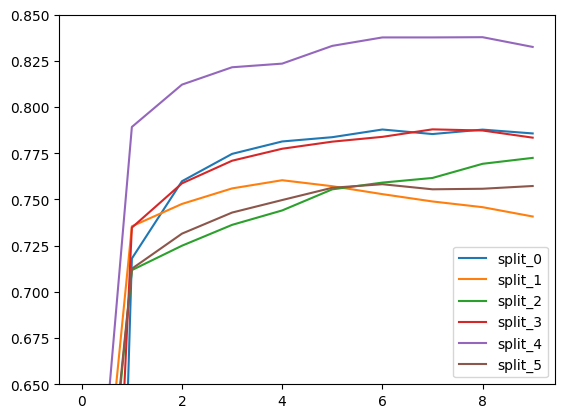

In [8]:
for  key, val in error_test['ConcatenatedCNN'].items():
    plt.plot(val, label=key)
ax = plt.gca()
ax.set_ylim([0.65, 0.85])
plt.legend()
plt.show()

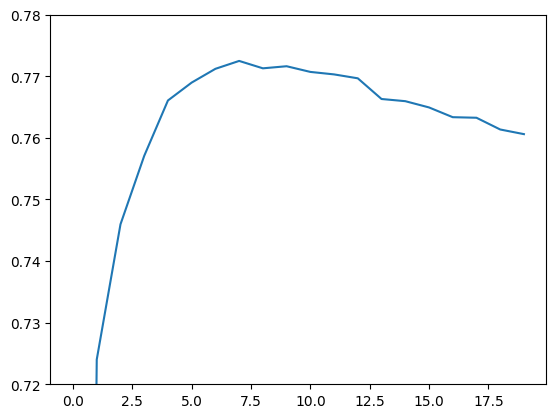

In [31]:
vals = list(error_test['ConcatenatedCNN'].values())

plt.plot(np.mean(vals, axis=0))
ax = plt.gca()
ax.set_ylim([0.72, 0.78])
plt.show()

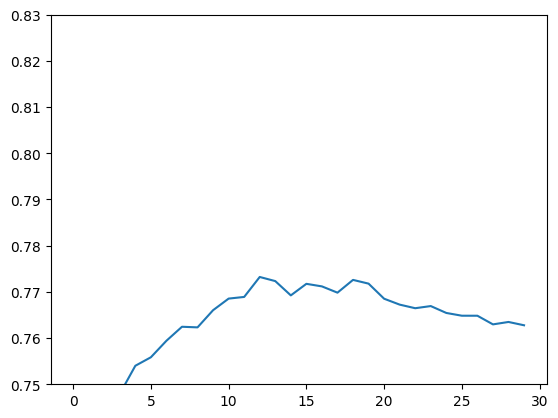

In [21]:
vals = list(error_test['ConcatenatedCNN'].values())

plt.plot(np.mean(vals, axis=0))
ax = plt.gca()
ax.set_ylim([0.75, 0.83])
plt.show()

In [ ]:
# reducir kernel_size a 3, aumentar el patience a 3 y reducir mas la capacidad de los modelos